In [78]:
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions 
from keras.preprocessing.image import load_img, img_to_array

In [79]:
modelVgg = VGG16()

In [80]:
modelVgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

<class 'PIL.Image.Image'>


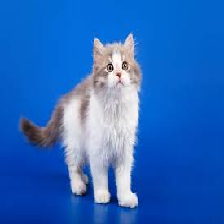

In [81]:
testImg = load_img('cat1.jpg', target_size=(224,224))
print(type(testImg))
testImg

In [82]:
# 이미지를 픽셀 값으로 변환
imgArr = img_to_array(testImg)
imgArr

array([[[  5., 102., 205.],
        [  5., 102., 205.],
        [  5., 102., 205.],
        ...,
        [  2.,  99., 202.],
        [  2.,  99., 202.],
        [  2.,  99., 202.]],

       [[  5., 102., 205.],
        [  5., 102., 205.],
        [  5., 102., 205.],
        ...,
        [  2.,  99., 202.],
        [  2.,  99., 202.],
        [  2.,  99., 202.]],

       [[  5., 102., 205.],
        [  5., 102., 205.],
        [  5., 102., 205.],
        ...,
        [  2.,  99., 202.],
        [  2.,  99., 202.],
        [  2.,  99., 202.]],

       ...,

       [[  0.,  45., 146.],
        [  0.,  45., 146.],
        [  0.,  45., 146.],
        ...,
        [  1.,  60., 160.],
        [  0.,  62., 161.],
        [  0.,  62., 161.]],

       [[  0.,  44., 145.],
        [  0.,  44., 145.],
        [  0.,  44., 145.],
        ...,
        [  0.,  59., 159.],
        [  0.,  61., 160.],
        [  0.,  61., 160.]],

       [[  0.,  43., 145.],
        [  0.,  43., 145.],
        [  0.,  

In [83]:
imgArr.shape

(224, 224, 3)

In [84]:
pred = modelVgg.predict(preprocess_input(imgArr.reshape(1,224,224,3)))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


array([[5.33185471e-07, 3.16628175e-05, 2.86642967e-06, 2.55227519e-06,
        1.62393462e-06, 5.83986503e-06, 1.25989345e-07, 1.42679642e-06,
        3.16737987e-06, 9.90060216e-05, 1.45589786e-06, 5.49495189e-06,
        1.07142546e-06, 4.84376960e-06, 2.37718109e-06, 4.34768367e-07,
        3.22943306e-05, 9.13796612e-06, 5.14977387e-07, 1.46482239e-06,
        2.28590170e-06, 7.53652857e-05, 4.68023318e-05, 4.99606449e-06,
        8.01003534e-06, 1.44905727e-07, 9.13229712e-07, 6.99055681e-06,
        6.03819387e-07, 3.51449603e-06, 1.09568717e-07, 8.51391064e-07,
        1.61446962e-07, 8.38182217e-08, 9.65077689e-08, 3.13291544e-08,
        1.84135516e-07, 3.81145959e-09, 3.16825276e-06, 6.74881619e-07,
        3.89507795e-06, 2.03088931e-07, 6.46822059e-07, 1.06093125e-06,
        5.51963194e-06, 3.91259469e-08, 2.52705513e-06, 4.11129065e-07,
        1.30217543e-08, 5.51040635e-08, 1.58648959e-07, 2.35729757e-07,
        9.16938745e-07, 1.10593601e-06, 7.22411500e-08, 2.575519

In [85]:
pred.shape

(1, 1000)

In [86]:
pred.argmax(axis=1)

array([283])

In [87]:
decode_predictions(pred, top=3)

[[('n02123394', 'Persian_cat', np.float32(0.43839782)),
  ('n02120079', 'Arctic_fox', np.float32(0.42778316)),
  ('n02114548', 'white_wolf', np.float32(0.02079863))]]

### 머그컵 이미지 분류

<class 'PIL.Image.Image'>


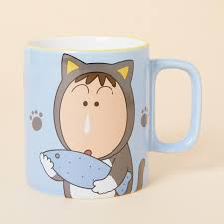

In [88]:
testImg1 = load_img('mugcup.jpg', target_size=(224,224))
print(type(testImg1))
testImg1

In [89]:
# 이미지를 픽셀 값으로 변환
imgArr = img_to_array(testImg1)
imgArr

array([[[246., 231., 212.],
        [246., 231., 212.],
        [246., 231., 212.],
        ...,
        [241., 225., 200.],
        [241., 225., 200.],
        [242., 224., 200.]],

       [[246., 231., 212.],
        [246., 231., 212.],
        [246., 231., 212.],
        ...,
        [241., 225., 200.],
        [241., 225., 200.],
        [242., 224., 200.]],

       [[246., 231., 212.],
        [246., 231., 212.],
        [246., 231., 212.],
        ...,
        [241., 225., 200.],
        [241., 225., 200.],
        [242., 224., 200.]],

       ...,

       [[235., 226., 211.],
        [235., 226., 211.],
        [235., 226., 211.],
        ...,
        [236., 223., 206.],
        [236., 223., 206.],
        [236., 223., 206.]],

       [[235., 226., 211.],
        [235., 226., 211.],
        [235., 226., 211.],
        ...,
        [236., 223., 206.],
        [236., 223., 206.],
        [236., 223., 206.]],

       [[235., 226., 209.],
        [235., 226., 209.],
        [235., 2

In [90]:
imgArr.shape

(224, 224, 3)

In [91]:
pred1 = modelVgg.predict(preprocess_input(imgArr.reshape(1,224,224,3)))
pred1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


array([[9.81517658e-08, 4.92356378e-07, 3.11094794e-08, 1.23500044e-07,
        1.31705306e-07, 2.57704215e-07, 5.63611238e-08, 2.41262114e-07,
        2.21105097e-07, 4.97016458e-07, 4.35976972e-07, 1.50488597e-06,
        1.65254482e-06, 5.03428907e-07, 1.34191384e-06, 4.77912295e-07,
        1.61525691e-06, 4.60928504e-07, 7.24399968e-07, 1.13269141e-06,
        8.29568734e-08, 2.17143082e-07, 1.17241552e-06, 2.23651256e-07,
        6.00864894e-07, 6.87160082e-07, 4.26188819e-07, 3.30945659e-06,
        1.73933540e-06, 2.27631813e-06, 1.87650542e-07, 1.01713374e-06,
        8.39831614e-07, 2.88650540e-07, 1.93773644e-07, 3.30002791e-07,
        8.78980131e-07, 3.48923237e-07, 1.24508620e-06, 6.57609576e-07,
        7.13335169e-07, 1.89213594e-07, 1.30302726e-06, 8.93921879e-07,
        1.03527088e-06, 1.27440592e-06, 1.56729220e-06, 1.94035192e-06,
        1.66131059e-07, 2.97700581e-07, 1.06516929e-07, 1.59140882e-06,
        2.08246229e-06, 2.86149952e-06, 7.88911166e-07, 4.654748

In [92]:
pred1.shape

(1, 1000)

In [93]:
pred1.argmax(axis=1)

array([504])

In [94]:
decode_predictions(pred1, top=3)

[[('n03063599', 'coffee_mug', np.float32(0.6057041)),
  ('n07930864', 'cup', np.float32(0.26221848)),
  ('n03063689', 'coffeepot', np.float32(0.030647164))]]